# StyleCLIP

Редактирование изображений -- очень важная и интересная задача в мире генеративных моделей. В этом ноутбуке мы с вами попробуем решить эту задачу на основе работы [StyleCLIP](https://arxiv.org/abs/2103.17249).

Данный метод позволяет редактировать изображения, сгенерированные [StyleGAN2](https://github.com/rosinality/stylegan2-pytorch), используя текстовые описания. Например, вы можете взять фотографию человека и с помощью текстовой подсказки "сделать волосы кудрявыми" изменить прическу на фотографии. Основная идея данной работы в том, чтобы "подвинуть" изначальный латент так, чтобы сгенерированное из него изображение лучше соответствовало предложенному промпту. Авторы предлагают два основных подхода:

- Оптимизация латентного вектора на основе CLIP Loss

- Обучение специального Mapper для сдвига

Более подробно про эти два подхода можно почитать в самой стате [StyleCLIP](https://arxiv.org/abs/2103.17249).

Мы с вами рассмотрим только одну часть предложенного метода, а именно оптимизацию для редактирования. Как уже было сказано, StyleCLIP оптимизирует латентный вектор [StyleGAN2](https://arxiv.org/abs/1912.04958) для более точного соотвествия заданному промпту.

Идея StyleCLIP с оптимизацией отображена на изображении ниже.




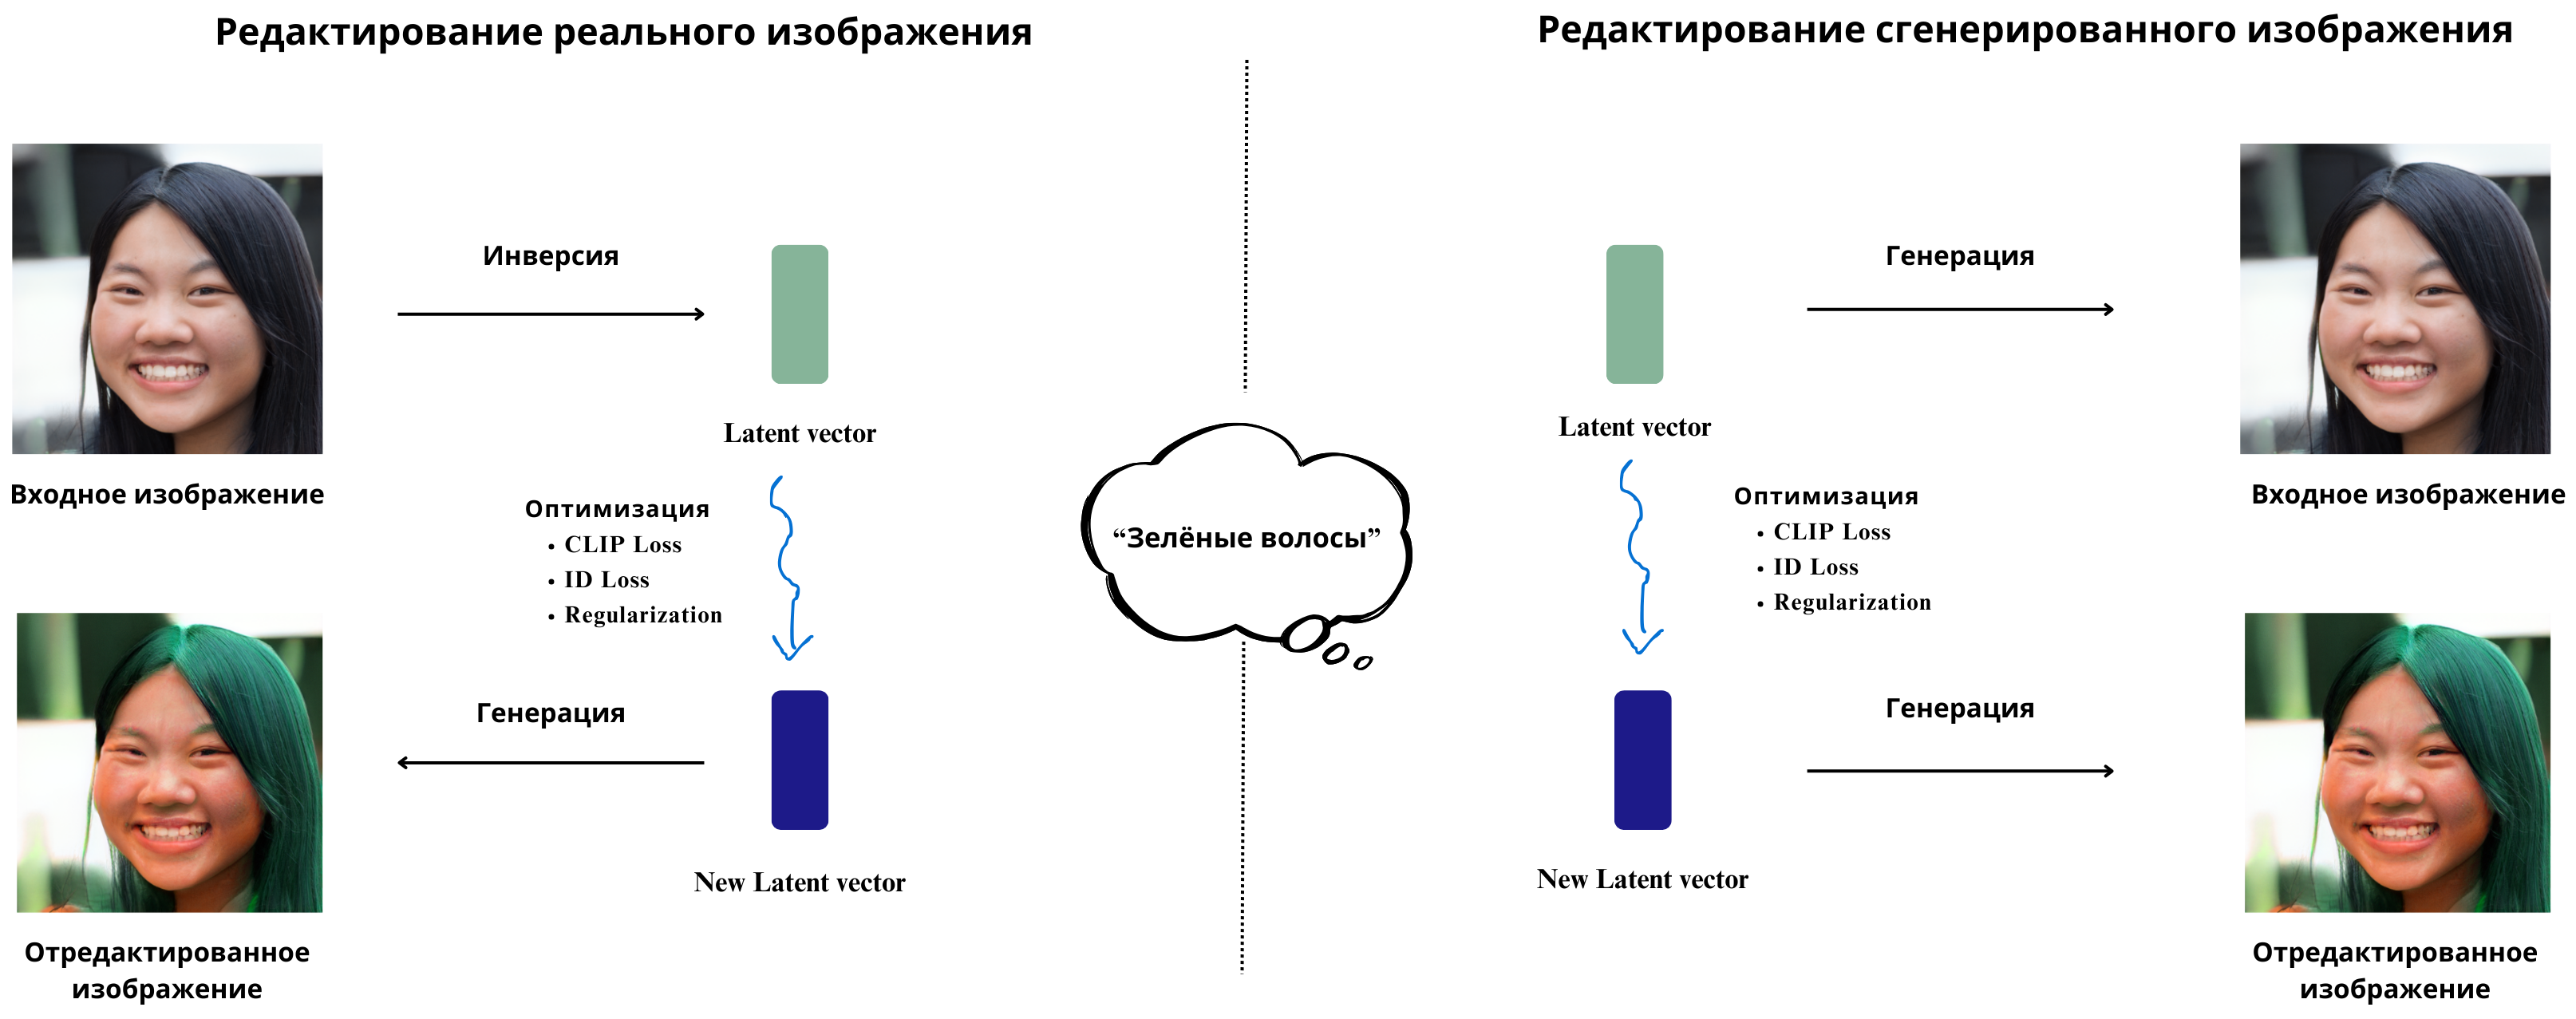

Наш план будет состоять в следующем:

1. Подготовка всех моделей для оптимизации

2. Реализация всех необходимых функций потерь:

  - CLIP Loss (1 балла)
  - ID Loss (1 балла)

3. Подготовка кода оптимизации (2 балла)

4. Выводы из полученных результатов (1 балл)

Давайте же попробуем написать код для этой оптимизации!

## Установка необходимых библиотек и подготовка окружения
Начнем с установки необходимых библиотек и клонирования репозитория StyleCLIP, чтобы использовать его методы.

In [ ]:
# Установка необходимых библиотек

# Установка зависимостей
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
# Установка дополнительных библиотек
!pip install Ninja

# Импорт нужных библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ikajapfs
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ikajapfs
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


In [3]:
# Клонирование репозитория StyleGAN2
!git clone https://github.com/rosinality/stylegan2-pytorch.git

Cloning into 'stylegan2-pytorch'...
remote: Enumerating objects: 395, done.
remote: Total 395 (delta 0), reused 0 (delta 0), pack-reused 395 (from 1)
Receiving objects: 100% (395/395), 122.51 MiB | 19.87 MiB/s, done.
Resolving deltas: 100% (205/205), done.


In [4]:
cd stylegan2-pytorch/

/content/stylegan2-pytorch


In [5]:
# Будем работать с конкретным сидом
torch.manual_seed(345)

## Основная идея статьи


Как уже было сказано, мы хотим редактировать изображение с помощью текста. Для этого будем использовать [CLIP](https://paperswithcode.com/method/clip) модель для некоторого гайданса в процессе оптимизации.

Задачу мы хотим построить следующим образом: имея исходный латентный вектор $w \in W$ мы хотим оптимизировать его под текстовый запрос $t$. Давайте подгрузм нашу модель и сгенерируем картинку для дальнейшей оптимизации.

Для работы со StyleGAN-2 нам для начала нужно скачать модель. Для скачивания мы используем следующий код:

In [6]:
import shutil
from google.colab import drive

drive.mount('/content/drive')

# 2. Копируем файл напрямую из твоего диска в Colab
src = '/content/drive/MyDrive/stylegan2-ffhq-config-f.pt'
dst = './stylegan2-ffhq-config-f.pt'

shutil.copy(src, dst)
print("Файл успешно скопирован в Colab!")

Mounted at /content/drive
Файл успешно скопирован в Colab!


In [7]:
!wget -O model_ir_se50.pth "https://dl.dropboxusercontent.com/s/qg7co4azsv5sacm/model_ir_se50.pth"

--2026-09-14 16:24:35--  https://dl.dropboxusercontent.com/s/qg7co4azsv5sacm/model_ir_se50.pth
Resolving dl.dropboxusercontent.com (dl.dropboxusercontent.com)... 162.125.81.15, 2620:100:6031:15::a27d:510f
Connecting to dl.dropboxusercontent.com (dl.dropboxusercontent.com)|162.125.81.15|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 175367323 (167M) [application/octet-stream]
Saving to: ‘model_ir_se50.pth’

model_ir_se50.pth   100%[===================>] 167.24M  15.3MB/s    in 13s     

2026-09-14 16:24:49 (13.3 MB/s) - ‘model_ir_se50.pth’ saved [175367323/175367323]



### Функция для генерации изображения из латентного вектора
Эта функция генерирует изображение из латентного вектора $z \in Z$ ($w \in W$), что нам пригодится для визуализации процесса редактирования.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
# 1. Если репозиторий семинара / rosinality еще не импортирован:
# Обычно класс Generator импортируется так:
try:
  from model import Generator
except ImportError:
  # Если модуль лежит в папке или репозитории models:
  try:
    from models.stylegan2.model import Generator
  except ImportError:
    from models import Generator

# 2. Инициализируем архитектуру генератора
# Для стандартного чекпоинта FFHQ разрешение 1024, latent 512, n_mlp 8
generator = Generator(size=1024, style_dim=512, n_mlp=8).to(device)

# 3. Загружаем скачанные веса
checkpoint_path = './stylegan2-ffhq-config-f.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# В чекпоинтах rosinality веса генератора лежат по ключу 'g_ema' (Exponential Moving Average)
if 'g_ema' in checkpoint:
  generator.load_state_dict(checkpoint['g_ema'])
elif 'g' in checkpoint:
  generator.load_state_dict(checkpoint['g'])
else:
  generator.load_state_dict(checkpoint)

generator.eval()
print('Generator успешно загружен и готов к генерации!')

Generator успешно загружен и готов к генерации!


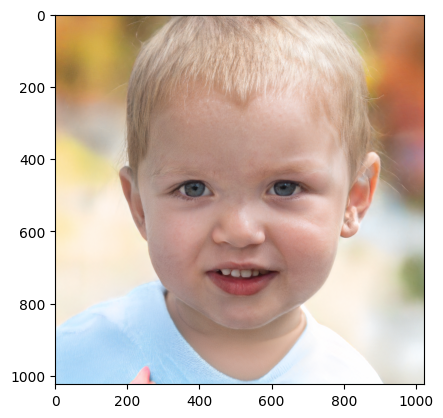

In [103]:
# Сгенерируем изображение
latent_z = torch.randn(1, 512, device=device) # Z noise
latent_z_generated = latent_z.mean(0, keepdim=True)

with torch.no_grad():
  latent_ws = generator.style(latent_z).repeat(1, 18, 1)
  target_img, _ = generator([latent_ws], input_is_latent=True, randomize_noise=False)

# Визуализируйте изначальную картинку
plt.imshow((target_img.detach().cpu().squeeze(0).clip(-1, 1).permute(1, 2, 0) + 1) / 2);

## Задача оптимизации

Теперь давайте подронее сформулируем задачу оптимизации.

Нам необходимо следующее:

- Отредактированное изображение соответствует текстовому запросу

- Сохраняет identity изначального человека.

Авторы предлагают следующий лосс для оптимизации:

$$\arg \min_{w \in W} D_{\text{CLIP}}(G(w), t) + \lambda_2 \|w - w_s\|_2 + \lambda_{\text{ID}} L_{\text{ID}}(w)
$$

Давайте разберёмся с каждой частью подробнее.

### CLIP loss

Начнём мы с CLIP loss.

 $D_{\text{CLIP}}$ — косинусное расстояние между эмбеддингами [CLIP](https://habr.com/ru/articles/539312/) для двух аргументов.

$$D_{\text{CLIP}}(G(w), t) = 1 - \frac{\langle E_{\text{CLIP}}(G(w)) \cdot E_{\text{CLIP}}(t) \rangle }{\|E_{\text{CLIP}}(G(w))\| \cdot \|E_{\text{CLIP}}(t)\|}$$


In [11]:
import torch
import clip


class CLIPLoss(torch.nn.Module):
    """
    Этот класс определяет пользовательскую функцию потерь на основе CLIP (Contrastive Language–Image Pre-training).
    Он измеряет сходство между изображением и текстовым описанием.
    """

    def __init__(self, stylegan_size=1024):
        """
        Инициализирует класс CLIPLoss.

        Args:
            opts: Объект, содержащий различные параметры, включая размер изображения StyleGAN.
        """
        super(CLIPLoss, self).__init__()
        # Загружаем предварительно обученную модель CLIP и функцию предварительной обработки
        self.model, self.preprocess = clip.load("ViT-B/32", device="cuda")
        self.model.eval()
        self.model.requires_grad_(False)

        # Дифференцируемый ресайз под входной размер ViT-B/32 (224x224)
        self.resizer = transforms.Resize((224, 224), antialias=True)
        # Стандартная нормализация CLIP
        self.normalize = transforms.Normalize(
            mean=(0.48145466, 0.4578275, 0.40821073),
            std=(0.26862954, 0.26130258, 0.27577711),
        )

    def forward(self, image, text):
        """
        Вычисляет потери CLIP между изображением и текстом.

        Args:
            image: Входной тензор изображения.
            text: Тензор текстового описания.

        Returns:
            Значение потерь CLIP.
        """
        # Меняем размерность изображения для получения нужного разрешения для CLIP
        image = (image + 1.0) / 2.0
        image = self.resizer(image)
        image = self.normalize(image)

        # Эмбеддинг картинки (градиенты обязательно сохраняются)
        img_embed = self.model.encode_image(image)
        img_embed = img_embed / img_embed.norm(dim=-1, keepdim=True)

        # Эмбеддинг текста (константа, без градиентов)
        with torch.no_grad():
          text_tokens = clip.tokenize(text).to(image.device)
          text_embed = self.model.encode_text(text_tokens)
          text_embed = text_embed / text_embed.norm(dim=-1, keepdim=True)

        D = (img_embed * text_embed).sum(dim=-1)

        return (1 - D).mean()

In [12]:
clip_loss = CLIPLoss()

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 110MiB/s]


### ID loss

Для сохранения identity человека использует специально предобученную модель [ArcFace](https://arxiv.org/abs/1801.07698), которая по фотографии вычисляет некоторые характерные для человека embedding вектора. Затем нам необходимо посчитать косинусное расстояние между ожидаемым embedding вектором и тем, что получается в процессе оптимизации:

$$ L_{\text{ID}}(w) = 1 - \langle R(G(w_s)), R(G(w)) \rangle $$

Обратите внимание, что здесь не используется дополнительная нормировка


Давайте подгрузим нашу модель и реализуем желаемую функцию потерь.


### Подгрузка модели

Далее у нас будет подгрузка самой модели, позаимствованная из репозитория [StyleCLIP](https://github.com/orpatashnik/StyleCLIP/blob/main/models/facial_recognition/helpers.py). Вы можете более подробно ознакомиться с кодом этой модели ниже, но мы не будем заострять на ней внимание.


In [13]:
# @title
from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Dropout, Sequential, Module

"""
Modified Backbone implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""
from collections import namedtuple
import torch
from torch.nn import Conv2d, BatchNorm2d, PReLU, ReLU, Sigmoid, MaxPool2d, AdaptiveAvgPool2d, Sequential, Module

"""
ArcFace implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""


class Flatten(Module):
	def forward(self, input):
		return input.view(input.size(0), -1)


def l2_norm(input, axis=1):
	norm = torch.norm(input, 2, axis, True)
	output = torch.div(input, norm)
	return output


class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])):
	""" A named tuple describing a ResNet block. """


def get_block(in_channel, depth, num_units, stride=2):
	return [Bottleneck(in_channel, depth, stride)] + [Bottleneck(depth, depth, 1) for i in range(num_units - 1)]


def get_blocks(num_layers):
	if num_layers == 50:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=4),
			get_block(in_channel=128, depth=256, num_units=14),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 100:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=13),
			get_block(in_channel=128, depth=256, num_units=30),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 152:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=8),
			get_block(in_channel=128, depth=256, num_units=36),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	else:
		raise ValueError("Invalid number of layers: {}. Must be one of [50, 100, 152]".format(num_layers))
	return blocks


class SEModule(Module):
	def __init__(self, channels, reduction):
		super(SEModule, self).__init__()
		self.avg_pool = AdaptiveAvgPool2d(1)
		self.fc1 = Conv2d(channels, channels // reduction, kernel_size=1, padding=0, bias=False)
		self.relu = ReLU(inplace=True)
		self.fc2 = Conv2d(channels // reduction, channels, kernel_size=1, padding=0, bias=False)
		self.sigmoid = Sigmoid()

	def forward(self, x):
		module_input = x
		x = self.avg_pool(x)
		x = self.fc1(x)
		x = self.relu(x)
		x = self.fc2(x)
		x = self.sigmoid(x)
		return module_input * x


class bottleneck_IR(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False), PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False), BatchNorm2d(depth)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class bottleneck_IR_SE(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR_SE, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False),
			PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False),
			BatchNorm2d(depth),
			SEModule(depth, 16)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class Backbone(Module):
	def __init__(self, input_size, num_layers, mode='ir', drop_ratio=0.4, affine=True):
		super(Backbone, self).__init__()
		assert input_size in [112, 224], "input_size should be 112 or 224"
		assert num_layers in [50, 100, 152], "num_layers should be 50, 100 or 152"
		assert mode in ['ir', 'ir_se'], "mode should be ir or ir_se"
		blocks = get_blocks(num_layers)
		if mode == 'ir':
			unit_module = bottleneck_IR
		elif mode == 'ir_se':
			unit_module = bottleneck_IR_SE
		self.input_layer = Sequential(Conv2d(3, 64, (3, 3), 1, 1, bias=False),
									  BatchNorm2d(64),
									  PReLU(64))
		if input_size == 112:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 7 * 7, 512),
			                               BatchNorm1d(512, affine=affine))
		else:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 14 * 14, 512),
			                               BatchNorm1d(512, affine=affine))

		modules = []
		for block in blocks:
			for bottleneck in block:
				modules.append(unit_module(bottleneck.in_channel,
										   bottleneck.depth,
										   bottleneck.stride))
		self.body = Sequential(*modules)

	def forward(self, x):
		x = self.input_layer(x)
		x = self.body(x)
		x = self.output_layer(x)
		return l2_norm(x)


def IR_50(input_size):
	"""Constructs a ir-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_101(input_size):
	"""Constructs a ir-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_152(input_size):
	"""Constructs a ir-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_SE_50(input_size):
	"""Constructs a ir_se-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_101(input_size):
	"""Constructs a ir_se-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_152(input_size):
	"""Constructs a ir_se-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir_se', drop_ratio=0.4, affine=False)
	return model

### ID loss

Теперь непосредственно реализуем нашу функцию потерь.

In [38]:
import torch
from torch import nn


class IDLoss(nn.Module):
    def __init__(self, model_weights, device='cuda'):
        super(IDLoss, self).__init__()
        print('Loading ResNet ArcFace')
        # Загружаем предобученную модель ResNet ArcFace для извлечения признаков лица.
        # input_size: размер входного изображения (112x112).
        self.facenet = Backbone(input_size=112, num_layers=50, drop_ratio=0.6, mode='ir_se')
        # Загружаем веса предобученной модели
        self.facenet.load_state_dict(torch.load(model_weights))
        self.pool = torch.nn.AdaptiveAvgPool2d((256, 256))
        self.face_pool = torch.nn.AdaptiveAvgPool2d((112, 112))
        self.facenet.eval()
        # Перемещаем модель ArcFace на GPU, если доступен.
        self.facenet.to(device)
        self.facenet.requires_grad_(False)


    def extract_feats(self, x):
        # Функция для извлечения эмбеддингов лица из изображения x.
        # Если размер изображения не 256x256, изменяем его с помощью пулинга.
        if x.shape[2] != 256:
            x = self.pool(x)
        # Обрезаем центральную область изображения (35:223, 32:220), содержащую лицо.
        x = x[:, :, 35:223, 32:220]
        # Изменяем размер обрезанной области до 112x112 с помощью пулинга.
        x = self.face_pool(x)
        # Извлекаем эмбеддинги лица с помощью модели ArcFace.
        x_feats = self.facenet(x)
        # Возвращаем извлеченные эмбеддинги.
        return x_feats

    def forward(self, y_hat, y):
        # Функция для вычисления ID Loss.
        # y_hat: отредактированное изображение.
        # y: исходное изображение.
        n_samples = y.shape[0]
        # Извлекаем признаки лица из исходного изображения.
        with torch.no_grad():
          y_feat = self.extract_feats(y).detach()

        # Извлекаем признаки лица из отредактированного изображения.
        y_hat_feat = self.extract_feats(y_hat)

        # Не забудьте сделать detach()!
        y_feat = y_feat.detach()


        # Считаем наш лосс
        loss = (y_feat * y_hat_feat).sum(dim=-1)

        return 1 - loss.mean()

In [39]:
# Загрузим нашу модель ArcFace
model_path = "/content/stylegan2-pytorch/model_ir_se50.pth"
id_loss = IDLoss(model_path, device)

Loading ResNet ArcFace


## Инициализация латентного вектора и текстовой подсказки
Определим латентный вектор
𝑊
W для исходного изображения и преобразуем текстовую подсказку в вектор с помощью CLIP, что будет служить нашей целью для редактирования.

## Оптимизация для редактирования изображения
Реализуем оптимизацию, используя Adam. На каждом шаге обновляется латентный вектор $w \in W$ для минимизации потерь CLIP, пока результат не будет похож на текстовую подсказку.

Основной псевдокод оптимизации представлен ниже:

```python

for step in range(num_steps):  # <----------- итерируемся по датасету несколько раз
    torch.cuda.empty_cache() # <------------- очищаем кэш модели
    optimizer.zero_grad()  # <------------- обуляем градиенты модели
    image, _ = generator([latent], input_is_latent=True, randomize_noise=False)  # <------------- получаем картинку из StyleGAN-2
    loss = clip_loss + l2_lambda * l2_loss + id_lambda * id_loss
    loss.backward()  # <------------------- считаем градиенты
    optimizer.step()  # <------------------ делаем шаг градиентного спуска
    if convergence:  # <------------------- в случае сходимости выходим из цикла
        break
```

Где полная функция потерь считается по формуле:
$$\arg \min_{w \in W} D_{\text{CLIP}}(G(w), t) + \lambda_2 \|w - w_s\|_2 + \lambda_{\text{ID}} L_{\text{ID}}(w)
$$

Дополнительно сохраните значения лосс функций для дальнейшей визуализации.


In [129]:
# Подготавливаем текстовый промпт для оптимизации, который будет направлять изменение изображения.
prompt = "a person with red hair"

# Токенизируем промпт с помощью CLIP tokenizer и перемещаем на устройство (CPU или GPU).
# clip.tokenize: функция из библиотеки CLIP для токенизации текста.
with torch.no_grad():
  text_inputs = torch.cat([clip.tokenize(prompt)]).to(device)

In [130]:
# Подготовим папку для сохранения результатов
import os
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

Работать предлагаем в пространстве $W^+$, давайте преобразуем наш вектор в styleSpace

In [131]:
latent = latent_ws.detach().clone().requires_grad_(True)

In [132]:
%matplotlib inline

In [133]:
import warnings

# Глушим конкретное предупреждение от модуля conv2d_gradfix
warnings.filterwarnings(
    "ignore",
    message="conv2d_gradfix not supported",
    category=UserWarning,
    module=".*conv2d_gradfix.*",
)

In [134]:
file_path = "/content/stylegan2-pytorch/lpips/__init__.py"

# Откроем файл и прочитаем его содержимое
with open(file_path, 'r') as file:
    lines = file.readlines()

# Заменим нужную строку
with open(file_path, 'w') as file:
    for line in lines:
        # Если в строке есть "compare_ssim", заменим на "structural_similarity"
        if "from skimage.measure import compare_ssim" in line:
            file.write("from skimage.metrics import structural_similarity\n")
        else:
            file.write(line)

print("Замена выполнена успешно!")

import lpips  # Библиотека для вычисления perceptual loss


Замена выполнена успешно!


In [135]:
# Загрузка Perceptual Loss (LPIPS)
perceptual_loss = lpips.PerceptualLoss(
      model="net-lin", net="alex", use_gpu=device
  )
print("LPIPS загружен.")
print("Генератор успешно загружен.")

Setting up Perceptual loss...


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /content/stylegan2-pytorch/lpips/weights/v0.1/alex.pth
...[net-lin [alex]] initialized
...Done
LPIPS загружен.
Генератор успешно загружен.


inversion_generated_z/Step [0/300], Loss: 0.7490234375


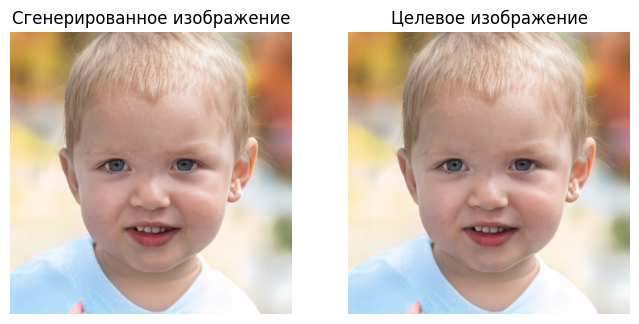

inversion_generated_z/Step [50/300], Loss: 0.6618094444274902


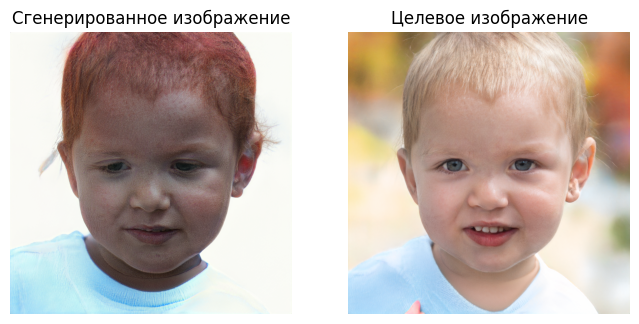

inversion_generated_z/Step [100/300], Loss: 0.6506597995758057


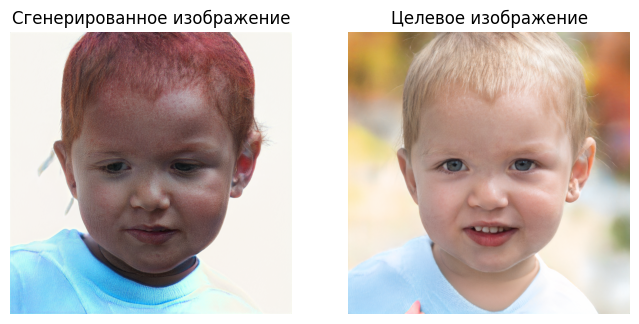

inversion_generated_z/Step [150/300], Loss: 0.6383530497550964


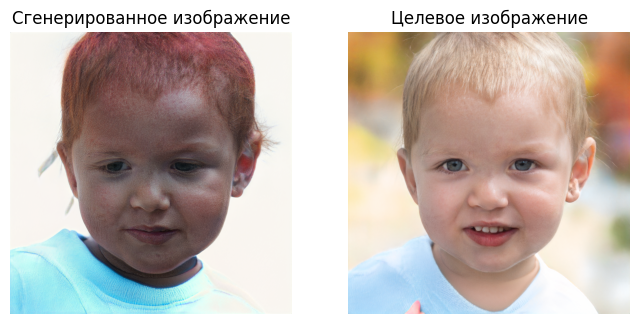

inversion_generated_z/Step [200/300], Loss: 0.6301031708717346


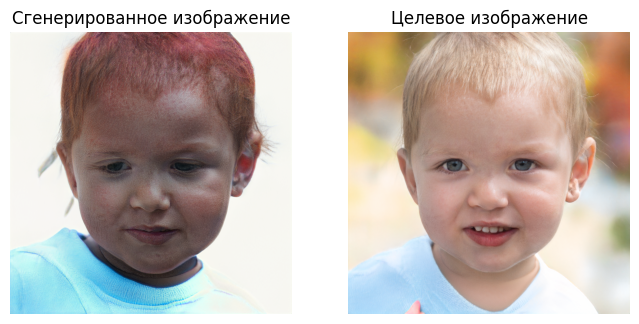

inversion_generated_z/Step [250/300], Loss: 0.6294500827789307


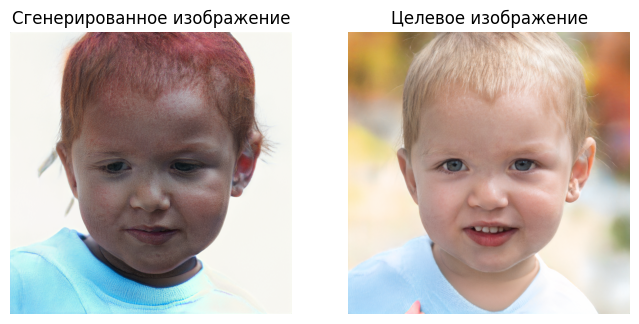

inversion_generated_z/Step [299/300], Loss: 0.6290967464447021


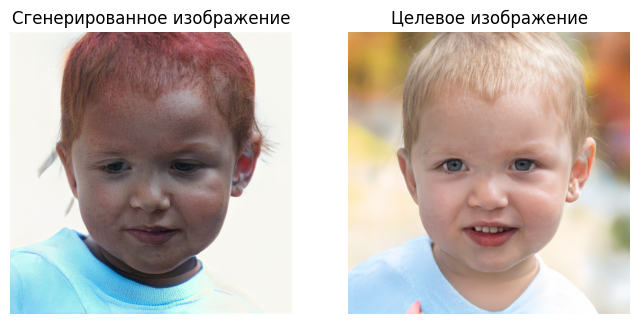

In [136]:
# Оптимизация для редактирования с помощью CLIP

num_steps = 300  # количество шагов оптимизации
l2_lambda = 0.01  # коэффициент для L2 регуляризации
id_lambda = 0.1  # коэффициент для identity loss
lpips_lambda = 0.3

# Создадим оптимизатор Adam
optimizer = torch.optim.Adam([latent], lr=0.05)
# А также выберем скедулер
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_steps, eta_min=1e-3)  # Плавное снижение скорости обучения

# Не забудьте сохранять лоссы для дальнейшей визуализации!
losses = {'id': [],
          'l2': [],
          'clip': [],
          'all': [],
          #'lpips': []
          }

# Напишем наш цикл оптимизации:
for step in range(num_steps):
    img_gen, ws = generator([latent], input_is_latent=True, randomize_noise=False)
    torch.cuda.empty_cache()
    optimizer.zero_grad()

    l_clip = clip_loss(img_gen, prompt)
    l_l2 = l2_lambda * torch.linalg.vector_norm(latent - latent_ws, ord=2)
    l_id = id_lambda * id_loss(img_gen, target_img)
    #l_lpips = lpips_lambda * perceptual_loss(img_gen, target_img)

    loss = l_clip + l_l2 + l_id
    loss.backward()
    optimizer.step()
    scheduler.step()

    losses['id'].append(l_id.item() / id_lambda)
    losses['l2'].append(l_l2.item())
    losses['clip'].append(l_clip.item())
    #losses['lpips'].append(l_lpips.item())
    losses['all'].append(loss.item())

    # Визуализация и вывод потерь
    if step % 50 == 0 or step == num_steps - 1:  # Каждые 50 шагов
        print(f"inversion_generated_z/Step [{step}/{num_steps}], Loss: {losses['all'][-1]}")  # Вывод текущих потерь
        fig, axs = plt.subplots(1, 2, figsize=(8, 16))  # Создание подграфиков для визуализации

        # Визуализация сгенерированного изображения
        axs[0].imshow((img_gen.cpu().detach()[0].clip(-1,1).permute(1, 2, 0) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")  # Заголовок для сгенерированного изображения
        axs[0].axis('off')  # Отключение осей

        # Визуализация целевого изображения
        axs[1].imshow((target_img.cpu().detach()[0].clip(-1,1).permute(1, 2, 0) + 1) / 2)
        axs[1].set_title("Целевое изображение")  # Заголовок для целевого изображения
        axs[1].axis('off')  # Отключение осей
        plt.show()

Визуализируйте лоссы в зависимости от step

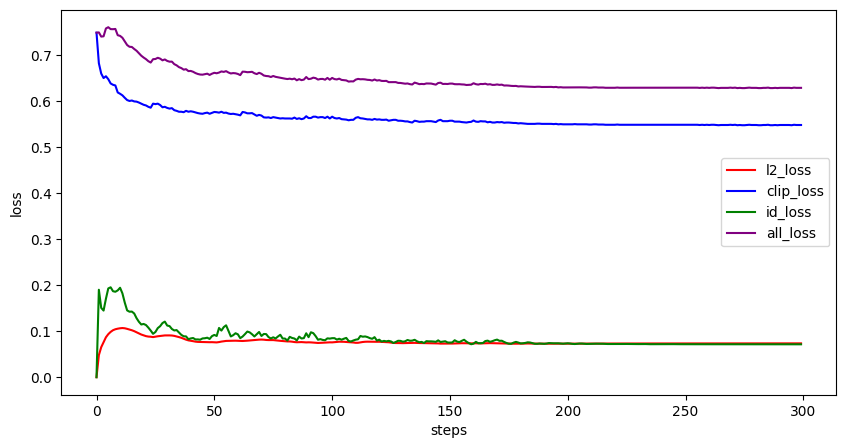

In [138]:
plt.figure(figsize=(10, 5))
plt.plot(losses['l2'], c='red', label='l2_loss')
plt.plot(losses['clip'], c='blue', label='clip_loss')
plt.plot(losses['id'], c='green', label='id_loss')
#plt.plot(losses['lpips'], c='brown', label='lpips_loss')
plt.plot(losses['all'], c='purple', label='all_loss')

plt.xlabel("steps")
plt.ylabel("loss")
plt.legend();